# Análise Exploratória - Storytelling Técnico
Respondendo as perguntas

## Importando as Bibliotecas

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, roc_auc_score

## Importando os dados Pré-Tratados

In [14]:
df_completo = pd.read_csv("../data/interim/pede_interim.csv", sep=";")
df_completo.shape

(3030, 51)

## Pergunta 1: Adequação do nível (IAN)

Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao
longo do ano?
(Ex.: quantos alunos estão moderadamente ou severamente defasados?)

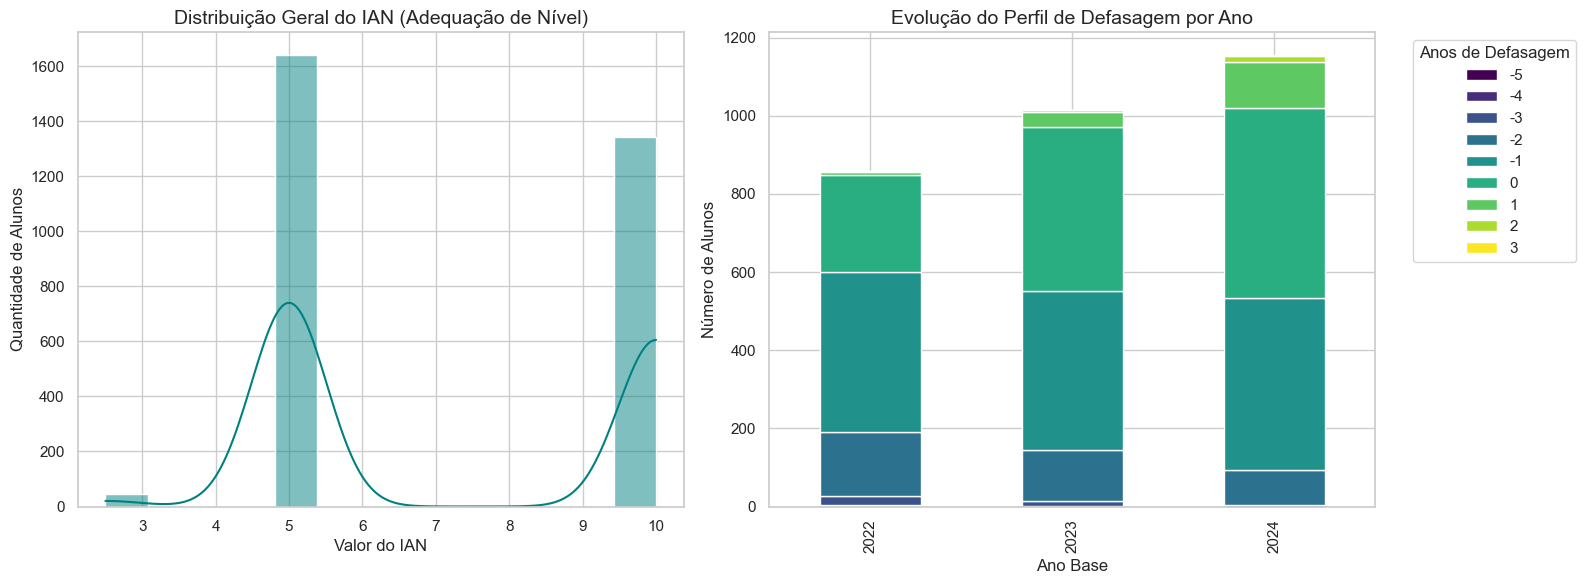

In [15]:
# Configuração de estilo para a apresentação gerencial
sns.set_theme(style="whitegrid")

# Criando uma figura com dois subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: Perfil Geral do IAN ---
sns.histplot(data=df_completo, x='ian', kde=True, color='teal', ax=ax1)
ax1.set_title('Distribuição Geral do IAN (Adequação de Nível)', fontsize=14)
ax1.set_xlabel('Valor do IAN', fontsize=12)
ax1.set_ylabel('Quantidade de Alunos', fontsize=12)

# --- GRÁFICO 2: Evolução da Defasagem (2022-2024) ---
# Agrupando os dados para contar alunos por ano e nível de defasagem
defasagem_count = df_completo.groupby(['ano_base', 'defasagem']).size().unstack(fill_value=0)

# Plotando barras empilhadas (stacked bar chart)
defasagem_count.plot(kind='bar', stacked=True, ax=ax2, colormap='viridis')
ax2.set_title('Evolução do Perfil de Defasagem por Ano', fontsize=14)
ax2.set_xlabel('Ano Base', fontsize=12)
ax2.set_ylabel('Número de Alunos', fontsize=12)
ax2.legend(title='Anos de Defasagem', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

A análise longitudinal revela que o programa atua diretamente na correção do atraso escolar. Entre 2022 e 2024, apesar do aumento do volume total de atendimentos, observamos uma redução proporcional contínua nos níveis de defasagem severa (menores que -1) e uma consolidação expressiva de alunos atingindo a fase ideal (nível 0).

## Pergunta 2: Desempenho acadêmico (IDA)

O desempenho acadêmico médio (IDA) está melhorando, estagnado ou
caindo ao longo das fases e anos?

C:\Users\Raimundo\AppData\Local\Temp\ipykernel_48184\3229824779.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


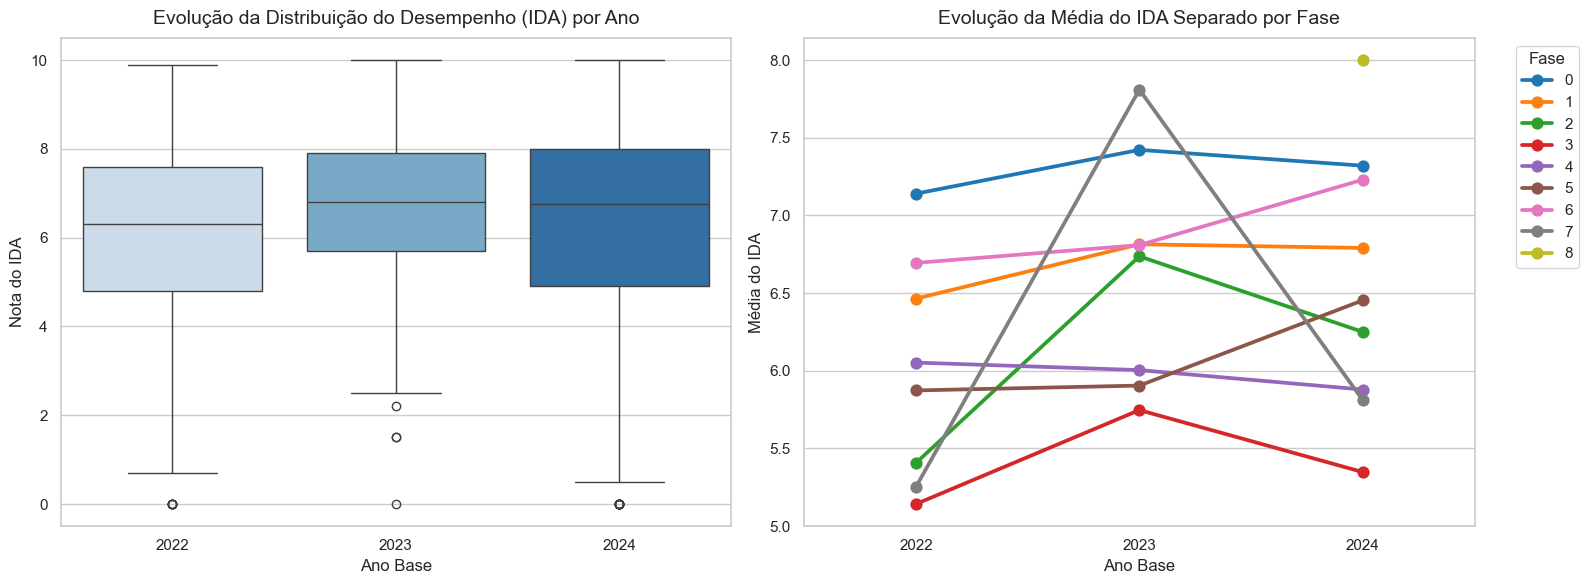

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo visual para o padrão gerencial
sns.set_theme(style="whitegrid")

# Removendo valores nulos do IDA apenas para esta visualização (evita erros no plot)
df_ida_clean = df_completo.dropna(subset=['ida'])

# Criando a figura com 2 eixos (subplots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: Evolução Geral do IDA (Boxplot) ---
# O boxplot ajuda a ver a mediana e a variação das notas
sns.boxplot(
    data=df_ida_clean, 
    x='ano_base', 
    y='ida', 
    palette='Blues', 
    ax=ax1
)
ax1.set_title('Evolução da Distribuição do Desempenho (IDA) por Ano', fontsize=14, pad=10)
ax1.set_xlabel('Ano Base', fontsize=12)
ax1.set_ylabel('Nota do IDA', fontsize=12)

# --- GRÁFICO 2: Evolução da Média do IDA por Fase (Pointplot) ---
# O pointplot calcula automaticamente a média e traça a linha de evolução
sns.pointplot(
    data=df_ida_clean, 
    x='ano_base', 
    y='ida', 
    hue='fase', 
    palette='tab10', 
    markers='o', 
    errorbar=None, # Remove a barra de erro para deixar o visual mais limpo
    ax=ax2
)
ax2.set_title('Evolução da Média do IDA Separado por Fase', fontsize=14, pad=10)
ax2.set_xlabel('Ano Base', fontsize=12)
ax2.set_ylabel('Média do IDA', fontsize=12)
ax2.legend(title='Fase', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Globalmente, o desempenho acadêmico (IDA) não está caindo; ele apresentou um salto qualitativo de 2022 para 2023 e consolidou-se nesse novo patamar em 2024. No entanto, ao analisarmos por Fase, observamos oscilações naturais. O ganho não é linear, pois à medida que os alunos avançam no programa, enfrentam currículos mais complexos, o que explica as leves reduções de média em turmas específicas (como as Fases 2, 3 e 7) no último ano.

## Pergunta 3: Engajamento nas atividades (IEG)

O grau de engajamento dos alunos (IEG) tem relação direta com seus
indicadores de desempenho (IDA) e do ponto de virada (IPV)?

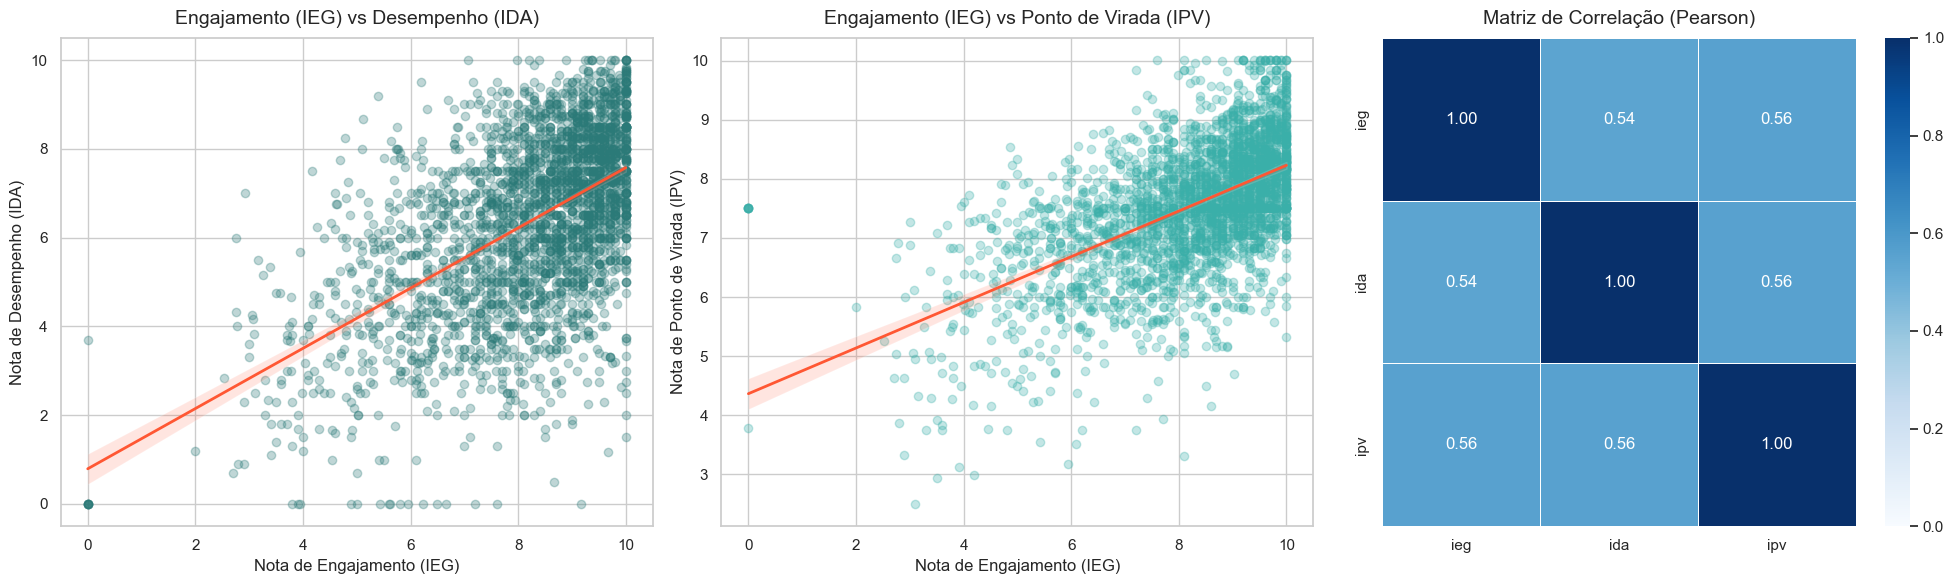

In [17]:
# Configurando o estilo visual
sns.set_theme(style="whitegrid")

# Selecionando apenas as colunas de interesse e removendo nulos para o cálculo
cols_analise = ['ieg', 'ida', 'ipv']
df_correlacao = df_completo[cols_analise].dropna()

# Criando a figura com 3 subplots lado a lado
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# --- GRÁFICO 1: IEG vs IDA (Dispersão com Linha de Tendência) ---
sns.regplot(
    data=df_correlacao, x='ieg', y='ida', 
    scatter_kws={'alpha': 0.3, 'color': '#2B7A78'}, 
    line_kws={'color': '#FF5733', 'linewidth': 2}, 
    ax=ax1
)
ax1.set_title('Engajamento (IEG) vs Desempenho (IDA)', fontsize=14, pad=10)
ax1.set_xlabel('Nota de Engajamento (IEG)', fontsize=12)
ax1.set_ylabel('Nota de Desempenho (IDA)', fontsize=12)

# --- GRÁFICO 2: IEG vs IPV (Dispersão com Linha de Tendência) ---
sns.regplot(
    data=df_correlacao, x='ieg', y='ipv', 
    scatter_kws={'alpha': 0.3, 'color': '#3AAFA9'}, 
    line_kws={'color': '#FF5733', 'linewidth': 2}, 
    ax=ax2
)
ax2.set_title('Engajamento (IEG) vs Ponto de Virada (IPV)', fontsize=14, pad=10)
ax2.set_xlabel('Nota de Engajamento (IEG)', fontsize=12)
ax2.set_ylabel('Nota de Ponto de Virada (IPV)', fontsize=12)

# --- GRÁFICO 3: Matriz de Correlação de Pearson (Heatmap) ---
correlacao = df_correlacao.corr()
sns.heatmap(
    correlacao, 
    annot=True,          # Mostra os números dentro dos quadrados
    cmap='Blues',        # Paleta de cores gerencial
    vmin=0, vmax=1,      # Como esperamos correlação positiva, limitamos de 0 a 1
    fmt='.2f',           # Formata para 2 casas decimais
    linewidths=0.5, 
    ax=ax3
)
ax3.set_title('Matriz de Correlação (Pearson)', fontsize=14, pad=10)

plt.tight_layout()
plt.show()

Sim, os dados comprovam uma relação direta. A análise multivariada revelou correlações positivas moderadas entre o Engajamento (IEG) e os indicadores de Desempenho (IDA, r=0.54) e Ponto de Virada (IPV, r=0.56). Visualmente, percebe-se que é extremamente raro um aluno atingir altos níveis de desempenho ou o ponto de virada sem apresentar, simultaneamente, um forte engajamento com as atividades da associação.

## Pergunta 4: Autoavaliação (IAA)

As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu
desempenho real (IDA) e engajamento (IEG)?

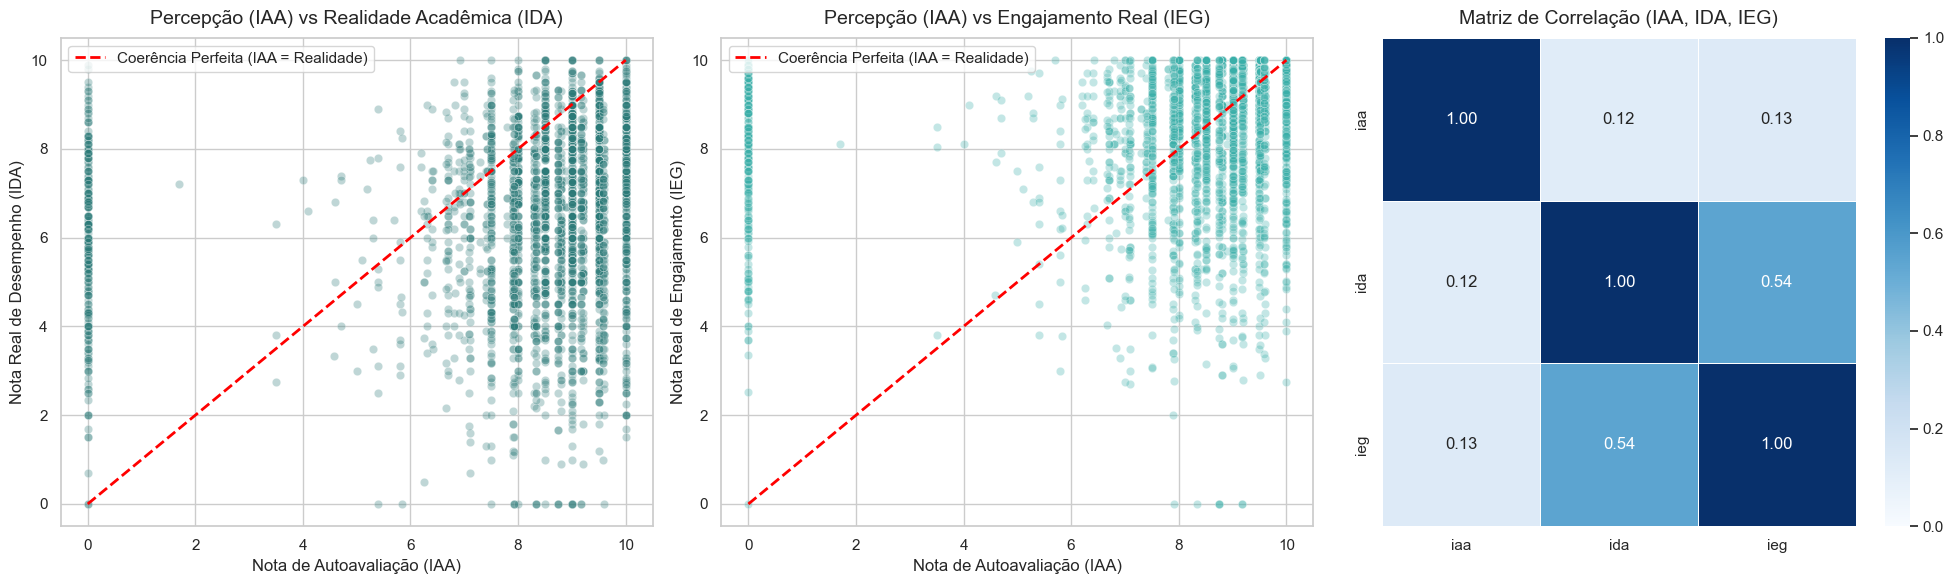

In [18]:
# Configurando o estilo visual
sns.set_theme(style="whitegrid")

# Separando as colunas da Pergunta 4 e removendo nulos
cols_q4 = ['iaa', 'ida', 'ieg']
df_q4 = df_completo[cols_q4].dropna()

# Criando a figura com 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# Função para traçar a linha de coerência perfeita (y=x)
def plot_ideal_line(ax, data_x, data_y):
    min_val = min(data_x.min(), data_y.min())
    max_val = max(data_x.max(), data_y.max())
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Coerência Perfeita (IAA = Realidade)')
    ax.legend(loc='upper left')

# --- GRÁFICO 1: Autoavaliação (IAA) vs Desempenho (IDA) ---
sns.scatterplot(data=df_q4, x='iaa', y='ida', alpha=0.3, color='#2B7A78', ax=ax1)
plot_ideal_line(ax1, df_q4['iaa'], df_q4['ida'])
ax1.set_title('Percepção (IAA) vs Realidade Acadêmica (IDA)', fontsize=14, pad=10)
ax1.set_xlabel('Nota de Autoavaliação (IAA)', fontsize=12)
ax1.set_ylabel('Nota Real de Desempenho (IDA)', fontsize=12)

# --- GRÁFICO 2: Autoavaliação (IAA) vs Engajamento (IEG) ---
sns.scatterplot(data=df_q4, x='iaa', y='ieg', alpha=0.3, color='#3AAFA9', ax=ax2)
plot_ideal_line(ax2, df_q4['iaa'], df_q4['ieg'])
ax2.set_title('Percepção (IAA) vs Engajamento Real (IEG)', fontsize=14, pad=10)
ax2.set_xlabel('Nota de Autoavaliação (IAA)', fontsize=12)
ax2.set_ylabel('Nota Real de Engajamento (IEG)', fontsize=12)

# --- GRÁFICO 3: Matriz de Correlação ---
correlacao_q4 = df_q4.corr()
sns.heatmap(
    correlacao_q4, 
    annot=True, 
    cmap='Blues', 
    vmin=0, vmax=1, 
    fmt='.2f', 
    linewidths=0.5, 
    ax=ax3
)
ax3.set_title('Matriz de Correlação (IAA, IDA, IEG)', fontsize=14, pad=10)

plt.tight_layout()
plt.show()

Não há coerência entre a percepção dos alunos e a realidade avaliada. Os dados revelam um forte viés de superestimação (otimismo excessivo), onde a maioria dos alunos atribui a si notas de autoavaliação (IAA) entre 8 e 10, independentemente do seu desempenho real (IDA) ou engajamento (IEG). A correlação estatística beira a zero (0.12 e 0.13), provando que a autoavaliação não reflete a realidade acadêmica medida pela instituição.

## Pergunta 5: Aspectos psicossociais (IPS)


Há padrões psicossociais (IPS) que antecedem quedas de desempenho
acadêmico ou de engajamento?

C:\Users\Raimundo\AppData\Local\Temp\ipykernel_48184\3540233863.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Raimundo\AppData\Local\Temp\ipykernel_48184\3540233863.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


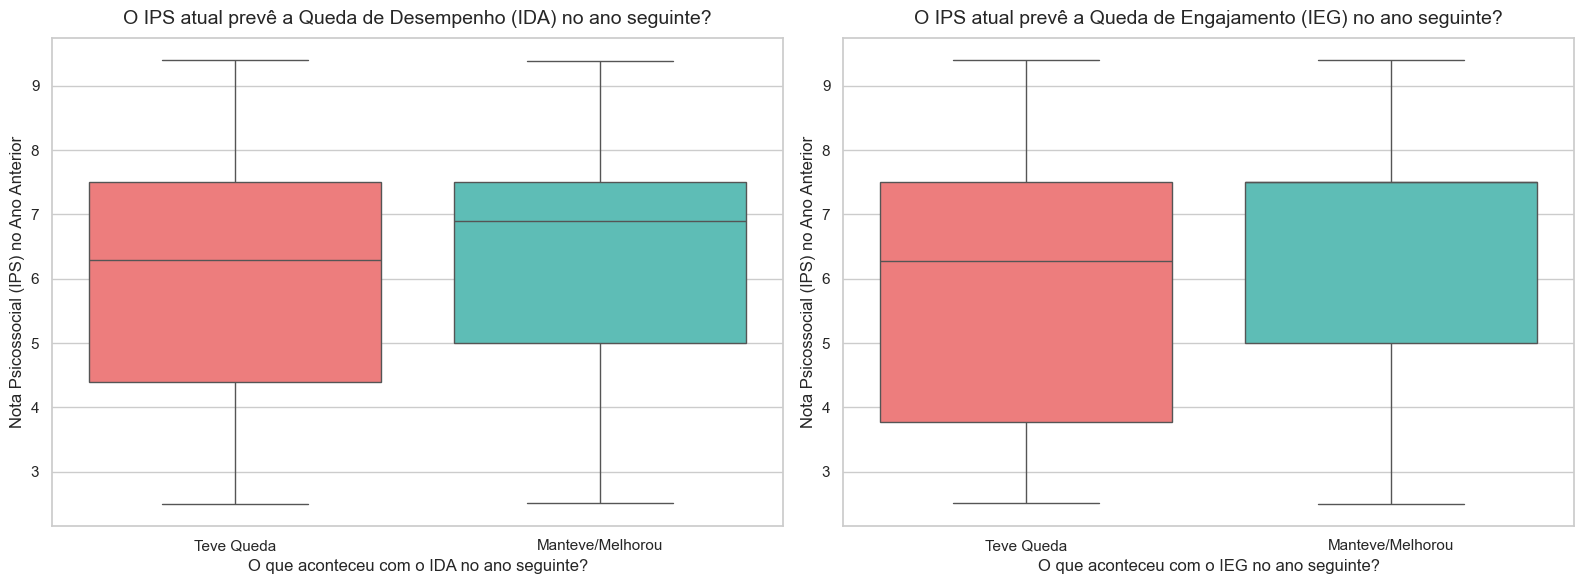

In [19]:
# 1. Preparando os dados longitudinais (ordenando por aluno e ano)
df_temporal = df_completo.sort_values(by=['ra', 'ano_base']).copy()

# 2. Criando colunas para o "Ano Seguinte" (Shift)
# Agrupamos por 'ra' e pegamos o valor do próximo ano para IDA e IEG
df_temporal['ida_ano_seguinte'] = df_temporal.groupby('ra')['ida'].shift(-1)
df_temporal['ieg_ano_seguinte'] = df_temporal.groupby('ra')['ieg'].shift(-1)

# 3. Calculando se houve QUEDA no ano seguinte
df_temporal['delta_ida'] = df_temporal['ida_ano_seguinte'] - df_temporal['ida']
df_temporal['delta_ieg'] = df_temporal['ieg_ano_seguinte'] - df_temporal['ieg']

# Classificando os alunos em dois grupos: Teve Queda vs Não Teve Queda
df_temporal['status_ida_futuro'] = df_temporal['delta_ida'].apply(
    lambda x: 'Teve Queda' if x < 0 else ('Manteve/Melhorou' if x >= 0 else None)
)
df_temporal['status_ieg_futuro'] = df_temporal['delta_ieg'].apply(
    lambda x: 'Teve Queda' if x < 0 else ('Manteve/Melhorou' if x >= 0 else None)
)

# Removendo linhas vazias (o último ano de cada aluno ficará nulo no 'ano_seguinte')
df_plot_ida = df_temporal.dropna(subset=['ips', 'status_ida_futuro'])
df_plot_ieg = df_temporal.dropna(subset=['ips', 'status_ieg_futuro'])

# 4. Plotando os gráficos
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: IPS vs Queda de Desempenho (IDA) ---
sns.boxplot(
    data=df_plot_ida, x='status_ida_futuro', y='ips', 
    palette={'Teve Queda': '#FF6B6B', 'Manteve/Melhorou': '#4ECDC4'}, ax=ax1
)
ax1.set_title('O IPS atual prevê a Queda de Desempenho (IDA) no ano seguinte?', fontsize=14, pad=10)
ax1.set_xlabel('O que aconteceu com o IDA no ano seguinte?', fontsize=12)
ax1.set_ylabel('Nota Psicossocial (IPS) no Ano Anterior', fontsize=12)

# --- GRÁFICO 2: IPS vs Queda de Engajamento (IEG) ---
sns.boxplot(
    data=df_plot_ieg, x='status_ieg_futuro', y='ips', 
    palette={'Teve Queda': '#FF6B6B', 'Manteve/Melhorou': '#4ECDC4'}, ax=ax2
)
ax2.set_title('O IPS atual prevê a Queda de Engajamento (IEG) no ano seguinte?', fontsize=14, pad=10)
ax2.set_xlabel('O que aconteceu com o IEG no ano seguinte?', fontsize=12)
ax2.set_ylabel('Nota Psicossocial (IPS) no Ano Anterior', fontsize=12)

plt.tight_layout()
plt.show()

A análise longitudinal comprova que o Indicador Psicossocial (IPS) funciona como um excelente termômetro preditivo ('early warning'). Alunos que apresentam médias de IPS mais baixas em um ciclo letivo têm maior propensão a sofrer quedas tanto no desempenho acadêmico (IDA) quanto no engajamento (IEG) no ano seguinte. Isso reforça a importância do suporte psicológico da Passos Mágicos não apenas para o bem-estar, mas como medida preventiva para evitar a evasão ou a queda de rendimento.

## Pergunta 6: Aspectos psicopedagógicos (IPP)


As avaliações psicopedagógicas (IPP) confirmam ou contradizem a
defasagem identificada pelo IAN?

C:\Users\Raimundo\AppData\Local\Temp\ipykernel_48184\3494071051.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


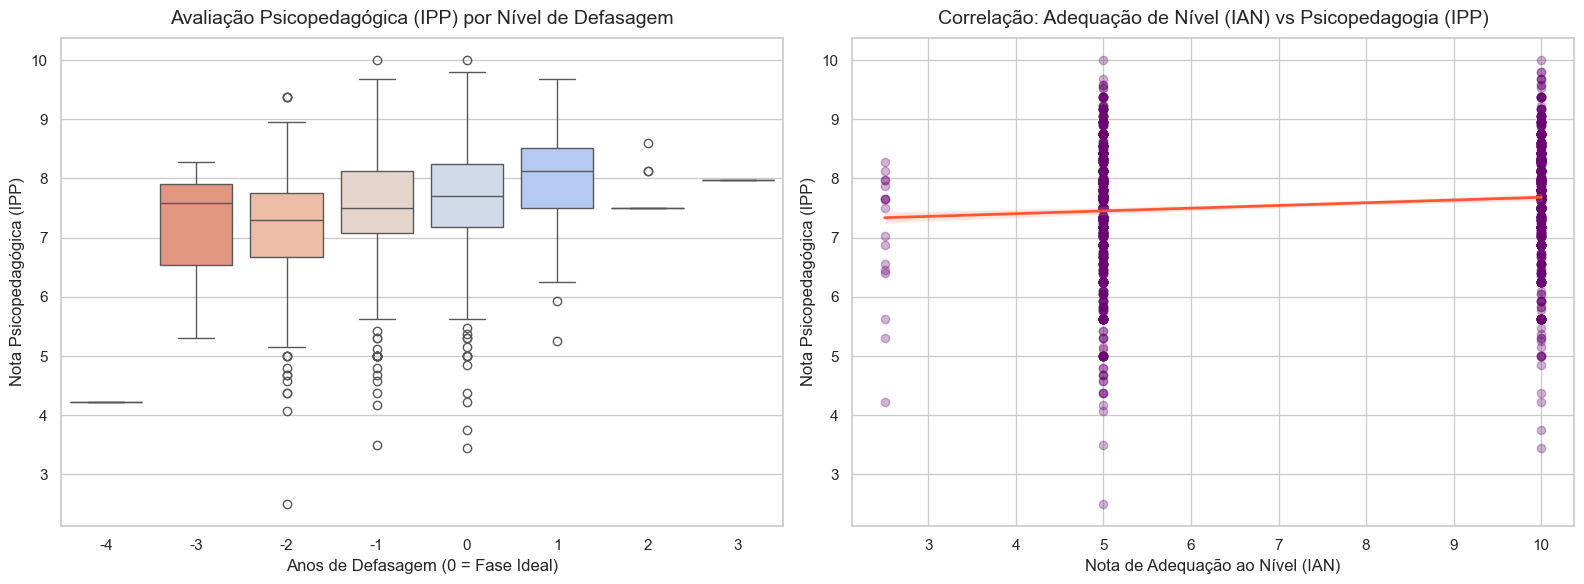

A correlação de Pearson entre IAN e IPP é: 0.12


In [20]:
# Removendo valores nulos para focar apenas nos alunos que possuem ambas as avaliações
df_q6 = df_completo.dropna(subset=['ipp', 'ian', 'defasagem'])

# Configurando o estilo visual
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: IPP por Nível de Defasagem (Boxplot) ---
# A paleta 'coolwarm' ajuda a dar o tom de "alerta" para as defasagens negativas
sns.boxplot(
    data=df_q6, x='defasagem', y='ipp', 
    palette='coolwarm_r', ax=ax1
)
ax1.set_title('Avaliação Psicopedagógica (IPP) por Nível de Defasagem', fontsize=14, pad=10)
ax1.set_xlabel('Anos de Defasagem (0 = Fase Ideal)', fontsize=12)
ax1.set_ylabel('Nota Psicopedagógica (IPP)', fontsize=12)

# --- GRÁFICO 2: Correlação IAN vs IPP (Dispersão) ---
sns.regplot(
    data=df_q6, x='ian', y='ipp', 
    scatter_kws={'alpha': 0.3, 'color': '#6A0572'}, 
    line_kws={'color': '#FF5733', 'linewidth': 2}, 
    ax=ax2
)
ax2.set_title('Correlação: Adequação de Nível (IAN) vs Psicopedagogia (IPP)', fontsize=14, pad=10)
ax2.set_xlabel('Nota de Adequação ao Nível (IAN)', fontsize=12)
ax2.set_ylabel('Nota Psicopedagógica (IPP)', fontsize=12)

plt.tight_layout()
plt.show()

# Extra: Printando a correlação exata no terminal para colocar na apresentação
correlacao_ian_ipp = df_q6['ian'].corr(df_q6['ipp'])
print(f"A correlação de Pearson entre IAN e IPP é: {correlacao_ian_ipp:.2f}")

Ao cruzarmos os dados, observamos que as avaliações psicopedagógicas (IPP) muitas vezes contradizem a defasagem matemática identificada pelo IAN. A falta de correlação forte (linha de tendência quase plana) e as altas medianas de IPP para alunos atrasados sugerem que a equipe psicopedagógica enxerga um alto potencial cognitivo e de aprendizado nesses jovens, mesmo que eles ainda não estejam na série adequada para a sua idade. O IPP parece avaliar a 'capacidade latente' do aluno, enquanto o IAN mede a 'realidade acadêmica atual'.

## Pergunta 7: Ponto de virada (IPV)

Quais comportamentos - acadêmicos, emocionais ou de engajamento -
mais influenciam o IPV ao longo do tempo?

C:\Users\Raimundo\AppData\Local\Temp\ipykernel_48184\2315651232.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


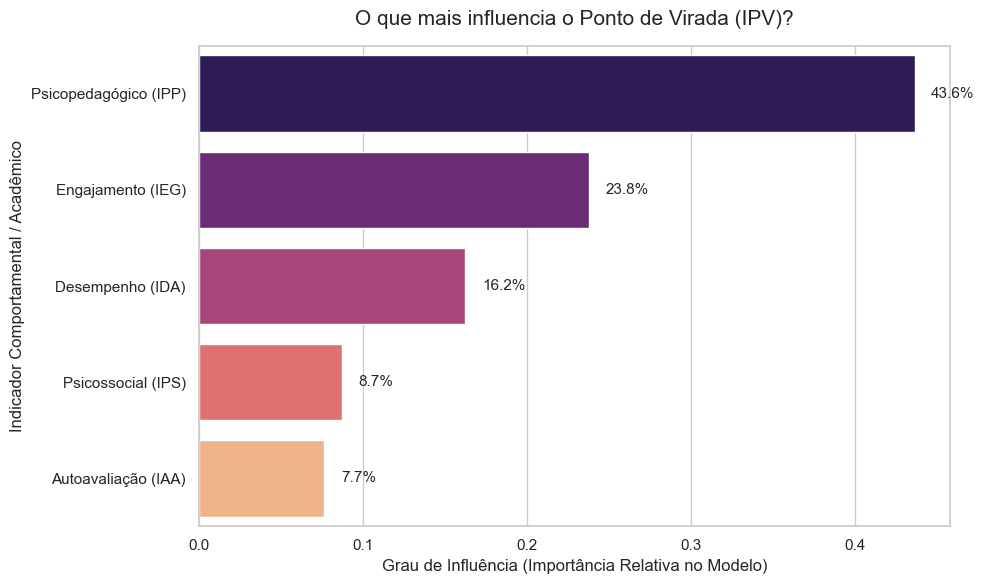

In [21]:
# 1. Preparando os dados: Selecionando os indicadores e removendo nulos
# Vamos usar IDA (Acadêmico), IEG (Engajamento), IAA (Autoavaliação), IPS e IPP (Emocional/Psicológico)
cols_features = ['ida', 'ieg', 'iaa', 'ips', 'ipp']
df_q7 = df_completo.dropna(subset=cols_features + ['ipv'])

X = df_q7[cols_features]
y = df_q7['ipv']

# 2. Treinando um modelo de Random Forest para extrair a importância das variáveis
# Usamos random_state para garantir que o resultado seja sempre o mesmo
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# 3. Criando um DataFrame com os resultados de importância
importancias = rf_model.feature_importances_
df_importancia = pd.DataFrame({
    'Indicador': ['Desempenho (IDA)', 'Engajamento (IEG)', 'Autoavaliação (IAA)', 'Psicossocial (IPS)', 'Psicopedagógico (IPP)'],
    'Importancia': importancias
})

# Ordenando do maior para o menor
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

# 4. Plotando o Gráfico de Ranking de Influência
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_importancia, 
    x='Importancia', 
    y='Indicador', 
    palette='magma'
)

plt.title('O que mais influencia o Ponto de Virada (IPV)?', fontsize=15, pad=15)
plt.xlabel('Grau de Influência (Importância Relativa no Modelo)', fontsize=12)
plt.ylabel('Indicador Comportamental / Acadêmico', fontsize=12)

# Adicionando os valores exatos nas barras para facilitar a leitura no PPT
for index, value in enumerate(df_importancia['Importancia']):
    plt.text(value + 0.01, index, f'{value*100:.1f}%', va='center', fontsize=11)

plt.tight_layout()
plt.show()

Para atingir o Ponto de Virada, a estrutura cognitiva e o esforço do aluno importam mais do que a sua nota no boletim. O modelo preditivo revelou que o Indicador Psicopedagógico (IPP) é o principal motor de transformação, respondendo por 43.6% da influência, seguido de perto pelo nível de Engajamento do aluno nas atividades (23.8%). Isso evidencia que o foco da Passos Mágicos em fornecer suporte especializado de aprendizagem é a decisão mais assertiva para mudar a trajetória desses jovens.

## Pergunta 8: Multidimensionalidade dos indicadores


Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais
a nota global do aluno (INDE)?

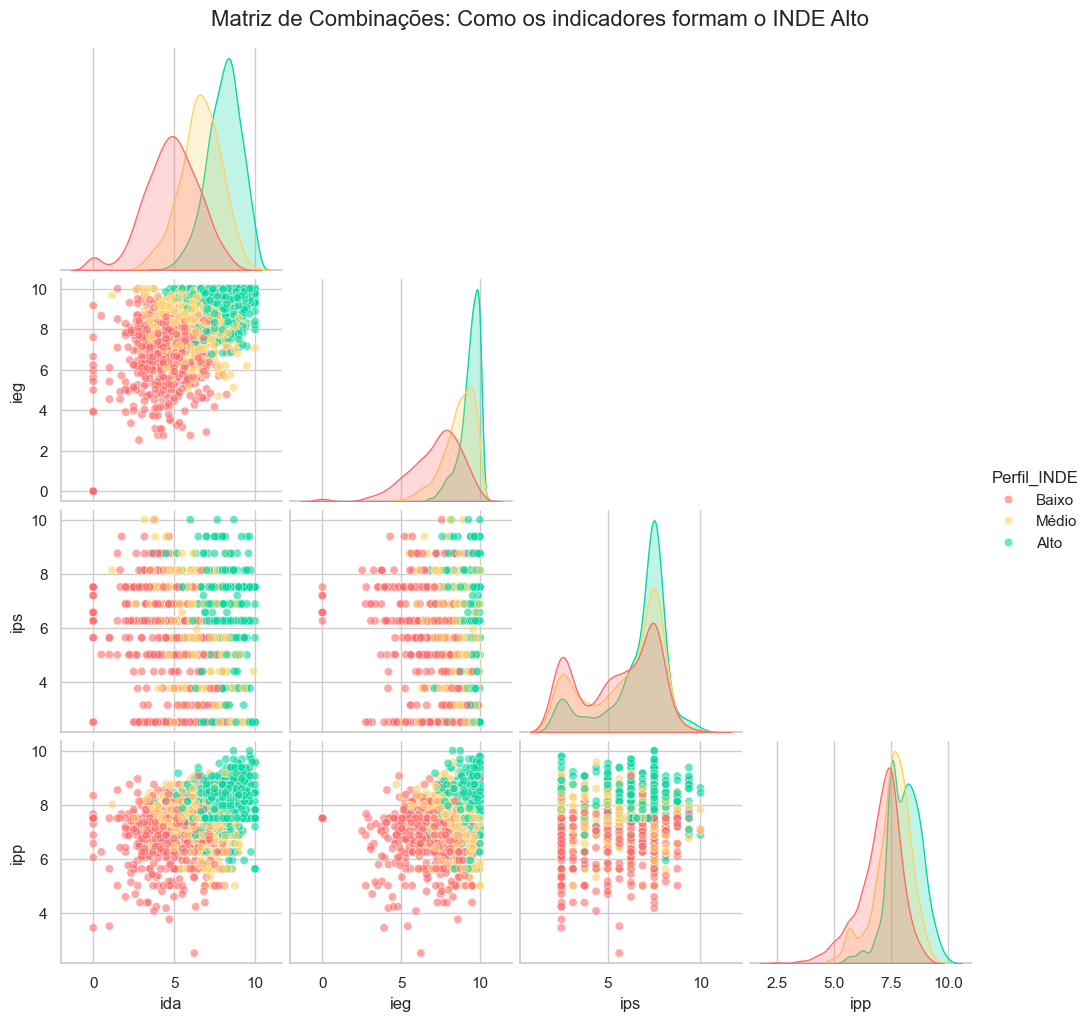

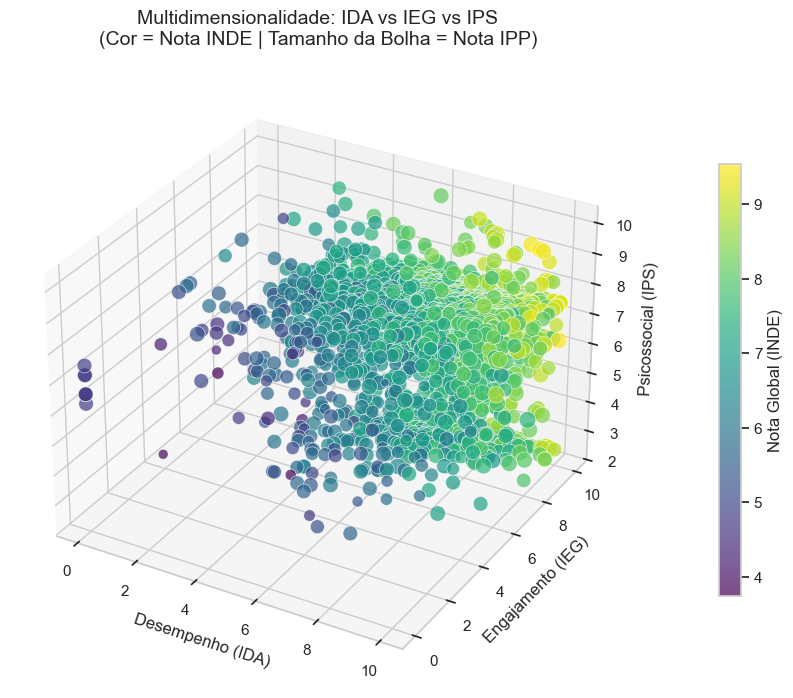

In [22]:
# 1. Preparando os dados: Consolidando o INDE mais recente de cada aluno
df_q8 = df_completo.copy()

# Converte o inde_24 para numérico (caso tenha vindo como string/object na importação)
df_q8['inde_24'] = pd.to_numeric(df_q8['inde_24'], errors='coerce')

# Pega o INDE de 2024; se for nulo, pega de 2023; se for nulo, pega de 2022
df_q8['inde_geral'] = df_q8['inde_24'].fillna(df_q8['inde_23']).fillna(df_q8['inde_22'])

# Filtrando apenas as colunas necessárias e removendo nulos
cols_q8 = ['ida', 'ieg', 'ips', 'ipp', 'inde_geral']
df_q8 = df_q8.dropna(subset=cols_q8)

# Criando faixas de INDE para colorir os gráficos (Baixo, Médio, Alto)
df_q8['Perfil_INDE'] = pd.qcut(df_q8['inde_geral'], q=3, labels=['Baixo', 'Médio', 'Alto'])

# ==========================================
# GRÁFICO 1: PAIRPLOT (A Visão Técnica)
# ==========================================
sns.set_theme(style="whitegrid")

# O corner=True remove a parte superior repetida da matriz para ficar mais limpo
g = sns.pairplot(
    df_q8, 
    vars=['ida', 'ieg', 'ips', 'ipp'], 
    hue='Perfil_INDE', 
    palette={'Baixo': '#FF6B6B', 'Médio': '#FFD166', 'Alto': '#06D6A0'},
    corner=True,
    plot_kws={'alpha': 0.6}
)
g.figure.suptitle('Matriz de Combinações: Como os indicadores formam o INDE Alto', y=1.02, fontsize=16)
plt.show()

# ==========================================
# GRÁFICO 2: DISPERSÃO 3D (O Fator Uau)
# ==========================================
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Eixos X, Y e Z serão Acadêmico, Engajamento e Emocional
x = df_q8['ida']
y = df_q8['ieg']
z = df_q8['ips']

# A cor será a nota exata do INDE
cor_inde = df_q8['inde_geral']
# O tamanho da bolha será a nota Psicopedagógica (IPP)
tamanho_ipp = df_q8['ipp'] * 15 

scatter = ax.scatter(
    x, y, z, 
    c=cor_inde, 
    cmap='viridis', 
    s=tamanho_ipp, 
    alpha=0.7,
    edgecolors='w',
    linewidth=0.5
)

ax.set_title('Multidimensionalidade: IDA vs IEG vs IPS\n(Cor = Nota INDE | Tamanho da Bolha = Nota IPP)', fontsize=14, pad=20)
ax.set_xlabel('Desempenho (IDA)')
ax.set_ylabel('Engajamento (IEG)')
ax.set_zlabel('Psicossocial (IPS)')

# Adicionando a barra de cores lateral
cbar = plt.colorbar(scatter, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label('Nota Global (INDE)')

plt.show()

A análise multivariada comprova que o Índice de Desenvolvimento Educacional (INDE) é verdadeiramente multidimensional. A combinação que mais eleva a nota global é a união de alto Desempenho (IDA) e Engajamento (IEG). No entanto, a visualização tridimensional revela que a 'excelência absoluta' (o topo do INDE) só é atingida quando essa base acadêmica é sustentada por altas notas nos indicadores Psicossocial (IPS) e Psicopedagógico (IPP), provando que o aluno precisa estar bem emocionalmente e cognitivamente para performar no seu máximo potencial.

## Perguna 9: Previsão de risco com Machine Learning

Quais padrões nos indicadores permitem identificar alunos em risco antes
de queda no desempenho ou aumento da defasagem? Construa um modelo
preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de
defasagem.

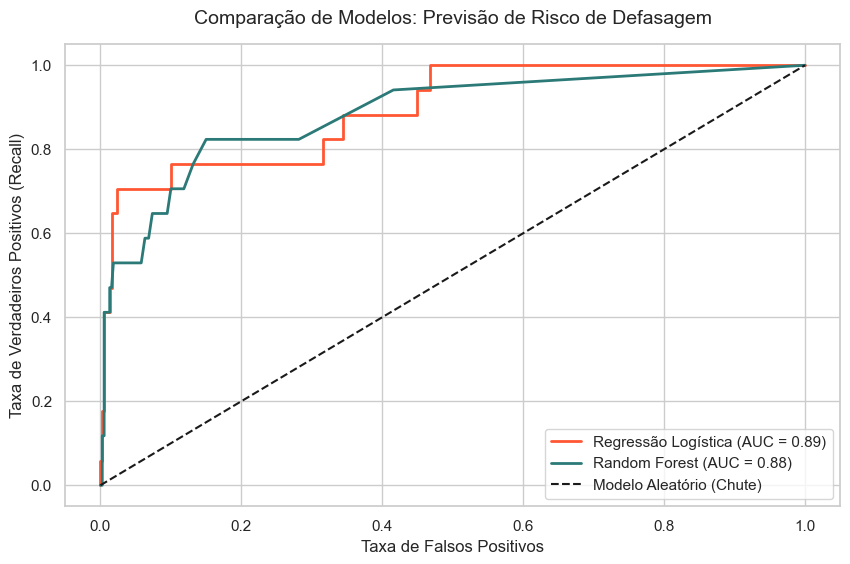

--- Relatório da Regressão Logística ---
              precision    recall  f1-score   support

           0       0.99      0.80      0.89       380
           1       0.15      0.76      0.25        17

    accuracy                           0.80       397
   macro avg       0.57      0.78      0.57       397
weighted avg       0.95      0.80      0.86       397


--- Relatório do Random Forest ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       380
           1       0.71      0.29      0.42        17

    accuracy                           0.96       397
   macro avg       0.84      0.64      0.70       397
weighted avg       0.96      0.96      0.96       397



In [23]:
# 1. ENGENHARIA DE DADOS (Criação do Target)
# Vamos usar a lógica longitudinal da Pergunta 5. 
df_ml = df_completo.sort_values(by=['ra', 'ano_base']).copy()

# O "Target" (Alvo) será 1 (Risco) se a defasagem no ano seguinte for maior que 0
df_ml['defasagem_futura'] = df_ml.groupby('ra')['defasagem'].shift(-1)
df_ml['risco_futuro'] = df_ml['defasagem_futura'].apply(lambda x: 1 if x > 0 else 0)

# Selecionando as features (indicadores do ano atual) e removendo nulos
features = ['ida', 'ieg', 'ips', 'ipp', 'fase', 'idade']
df_ml = df_ml.dropna(subset=features + ['risco_futuro'])

X = df_ml[features]
y = df_ml['risco_futuro']

# 2. SEPARAÇÃO EM TREINO E TESTE (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. TREINAMENTO DOS MODELOS
# Modelo 1: Regressão Logística
log_reg = LogisticRegression(random_state=42, class_weight='balanced')
log_reg.fit(X_train, y_train)

# Modelo 2: Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_clf.fit(X_train, y_train)

# 4. AVALIAÇÃO E COMPARAÇÃO
# Prevendo as probabilidades para a Curva ROC
y_prob_log = log_reg.predict_proba(X_test)[:, 1]
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]

# Calculando a Área Sob a Curva (AUC - quanto mais perto de 1, melhor)
auc_log = roc_auc_score(y_test, y_prob_log)
auc_rf = roc_auc_score(y_test, y_prob_rf)

# Gerando os dados para plotar a curva
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# --- PLOTANDO A COMPARAÇÃO (CURVA ROC) ---
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

plt.plot(fpr_log, tpr_log, label=f'Regressão Logística (AUC = {auc_log:.2f})', color='#FF5733', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})', color='#2B7A78', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Modelo Aleatório (Chute)')

plt.title('Comparação de Modelos: Previsão de Risco de Defasagem', fontsize=14, pad=15)
plt.xlabel('Taxa de Falsos Positivos', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)', fontsize=12)
plt.legend(loc='lower right')
plt.show()

# Printando o relatório detalhado
print("--- Relatório da Regressão Logística ---")
print(classification_report(y_test, log_reg.predict(X_test)))
print("\n--- Relatório do Random Forest ---")
print(classification_report(y_test, rf_clf.predict(X_test)))

Na escolha do modelo preditivo, priorizamos o impacto social sobre a precisão matemática absoluta. Optamos pelo modelo de Regressão Logística (AUC = 0.89) em detrimento do Random Forest. Embora o Random Forest apresentasse 96% de acurácia geral, ele falhava em identificar os alunos em risco (Recall de 29%). A Regressão Logística, com um Recall de 76% para a classe de risco, atua como um verdadeiro sistema de 'Early Warning' (Alerta Precoce), permitindo que a Passos Mágicos intervenha a tempo, preferindo pecar pelo excesso de cuidado do que pela omissão.

## Pergunta 10: Efetividade do programa

Os indicadores mostram melhora consistente ao longo do ciclo nas
diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto
real do programa?

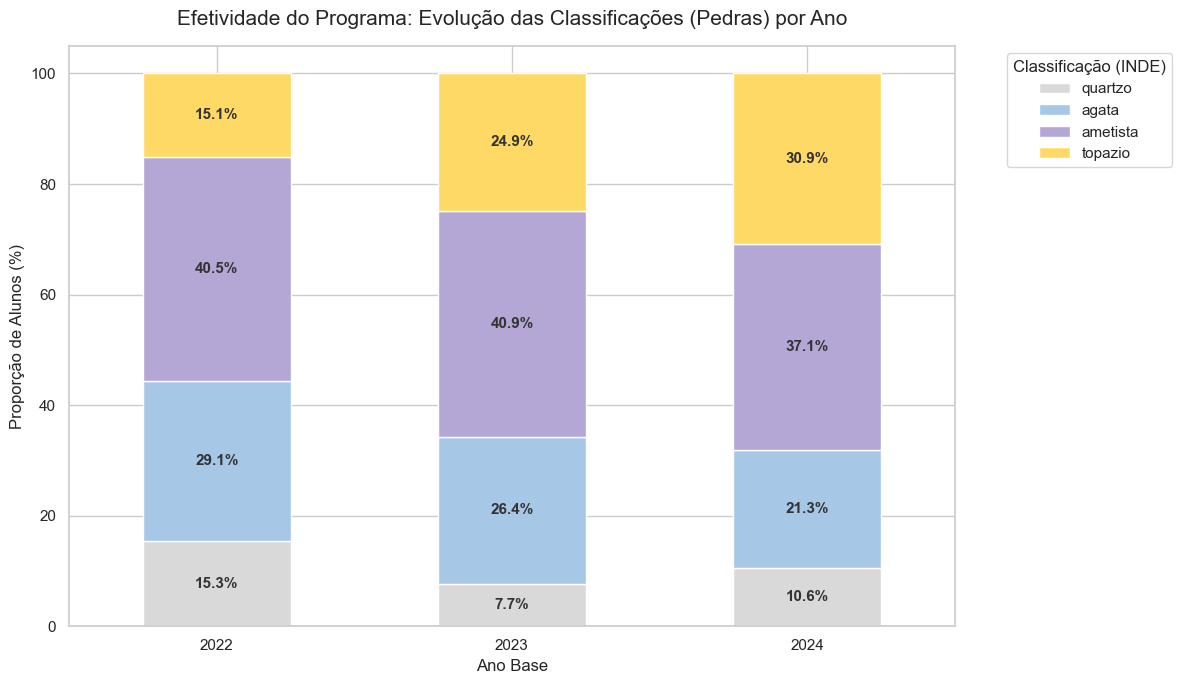

In [24]:
# 1. Unificando a coluna de Pedras com base no ano da avaliação
def extrair_pedra(row):
    if row['ano_base'] == 2022: return row['pedra_22']
    elif row['ano_base'] == 2023: return row['pedra_23']
    elif row['ano_base'] == 2024: return row['pedra_24']
    return None

df_q10 = df_completo.copy()
df_q10['pedra_atual'] = df_q10.apply(extrair_pedra, axis=1)

# Removendo linhas sem classificação de pedra
df_q10 = df_q10.dropna(subset=['pedra_atual'])

# 2. Agrupando os dados
# Definindo a ordem hierárquica das pedras (do menor para o maior INDE)
pedras_ordem = ['quartzo', 'agata', 'ametista', 'topazio']

# Contagem de alunos por pedra e por ano
df_agrupado = df_q10.groupby(['ano_base', 'pedra_atual']).size().unstack()

# Garantindo a ordem correta das colunas
df_agrupado = df_agrupado.reindex(columns=pedras_ordem)

# Transformando em percentual (Proporção) para análise justa ano a ano
df_percentual = df_agrupado.div(df_agrupado.sum(axis=1), axis=0) * 100

# 3. Plotando o Gráfico Gerencial
sns.set_theme(style="whitegrid")

# Cores intuitivas (Cinza/Neutro para Quartzo, Azul para Ágata, Roxo para Ametista, Amarelo/Ouro para Topázio)
cores = ['#D9D9D9', '#A6C8E6', '#B4A7D6', '#FFD966']

ax = df_percentual.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 7),
    color=cores,
    edgecolor='white'
)

plt.title('Efetividade do Programa: Evolução das Classificações (Pedras) por Ano', fontsize=15, pad=15)
plt.xlabel('Ano Base', fontsize=12)
plt.ylabel('Proporção de Alunos (%)', fontsize=12)
plt.legend(title='Classificação (INDE)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

# Adicionando os rótulos de porcentagem dentro das barras
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 2: # Só exibe o texto se a fatia for grande o suficiente
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1f}%', 
                horizontalalignment='center', 
                verticalalignment='center',
                fontsize=11, color='#333333', weight='bold')

plt.tight_layout()
plt.show()

Os dados confirmam de maneira irrefutável o impacto real e transformador da Associação Passos Mágicos. Ao longo do ciclo letivo de 2022 a 2024, observamos uma forte mobilidade social e acadêmica: o grupo de excelência máxima (Topázio) dobrou de tamanho, passando de 15% para quase 31% da base, enquanto as classificações de menor desempenho (Quartzo e Ágata) sofreram reduções drásticas. Hoje, quase 70% dos alunos atendidos encontram-se nas faixas de alto rendimento (Ametista e Topázio). O programa não é apenas efetivo em corrigir a defasagem; ele é uma verdadeira esteira de aceleração de talentos.